In [1]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
dataset = pd.read_csv('/content/Churn_Modelling.csv')
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# dependent and independent features
X = dataset.iloc[:, 3:13]
y = dataset.iloc[:, -1]

In [5]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [6]:
y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


## Feature Engineering

In [7]:
Geography = pd.get_dummies(X['Geography'], drop_first = True)
Gender = pd.get_dummies(X['Gender'], drop_first = True)

In [8]:
X = X.drop(['Geography', 'Gender'], axis = 1)
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64
9996,516,35,10,57369.61,1,1,1,101699.77
9997,709,36,7,0.00,1,0,1,42085.58
9998,772,42,3,75075.31,2,1,0,92888.52


In [9]:
X = pd.concat([X, Geography, Gender], axis = 1)
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


In [10]:
# Train and test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [11]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [12]:
X_train

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

In [13]:
X_test

array([[-0.55204276, -0.36890377,  1.04473698, ...,  1.75486502,
        -0.57369368, -1.09168714],
       [-1.31490297,  0.10961719, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       [ 0.57162971,  0.30102557,  1.04473698, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ..., -0.5698444 ,
         1.74309049,  0.91601335],
       [-0.00566991, -0.46460796, -0.33936434, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-0.79945688, -0.84742473,  1.04473698, ...,  1.75486502,
        -0.57369368,  0.91601335]])

## ANN

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import ReLU, PReLU, LeakyReLU, ELU
from tensorflow.keras.layers import Dropout

In [15]:
# initialzing the ann
classifier = Sequential()

In [16]:
X_train.shape

(8000, 11)

In [32]:
# # adding the input layer
# classifier.add(Dense(units= 11, activation= 'relu'))
# classifier.add(Dropout(0.2))

In [17]:
# adding the input layer
classifier.add(Dense(units= 11, activation= 'relu'))

In [18]:
# adding the first hidden layer
classifier.add(Dense(units= 7, activation= 'relu'))

In [19]:
# adding the second hidden layer
# classifier.add(Dense(units= 6, kernel_initializer='he_uniform', activation= 'relu')) for relu
classifier.add(Dense(units= 6, activation= 'relu'))

In [20]:
# adding the output layer
# classifier.add(Dense(units= 1, kernel_initializer='glorot_uniform', activation= 'sigmoid')) for sigmoid
classifier.add(Dense(units= 1, activation= 'relu'))

In [21]:
# import tensorflow
# opt = tensorflow.keras.optimizers.Adam(learning_rate= 0.001)
# classifier.compile(optimizer= 'opt', loss= 'binary_crossentropy', metrics= ['accuracy'])
classifier.compile(optimizer= 'adam', loss= 'binary_crossentropy', metrics= ['accuracy'])

In [22]:
# model_history = classifier.fit(X_train, y_train, validation_split= 0.33, batch_size= 10, epochs = 1000)

In [23]:
# Early stopping is used when the model accucracy is not at all increasing, automatically the training of the model will stop
import tensorflow as tf
earlystopping = tf.keras.callbacks.EarlyStopping(
    monitor= "val_loss",
    min_delta= 0.001,
    patience= 20,
    verbose= 1,
    mode= "auto",
    baseline= None,
    restore_best_weights= False,
    start_from_epoch= 0,
)

In [24]:
model_history = classifier.fit(X_train, y_train, validation_split= 0.33, batch_size= 10, epochs = 1000, callbacks= earlystopping)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7539 - loss: 1.0639 - val_accuracy: 0.7671 - val_loss: 0.7290
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7792 - loss: 0.6236 - val_accuracy: 0.7849 - val_loss: 0.5371
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7886 - loss: 0.4860 - val_accuracy: 0.7955 - val_loss: 0.4880
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7964 - loss: 0.4657 - val_accuracy: 0.7959 - val_loss: 0.4704
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8015 - loss: 0.4465 - val_accuracy: 0.7967 - val_loss: 0.4586
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8054 - loss: 0.4343 - val_accuracy: 0.8008 - val_loss: 0.4500
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8106 - loss: 0.4280 - val_accuracy: 0.8050 - val_loss: 0.4543
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8205 - loss: 0.4223 - 

In [25]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

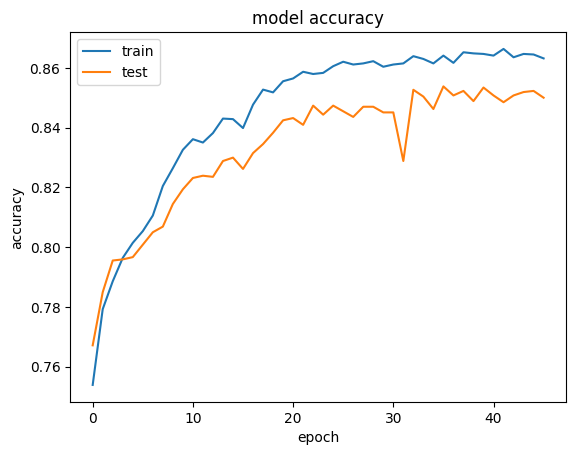

In [26]:
# summarize the plot history
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['train', 'test'], loc = 'upper left')
plt.show()

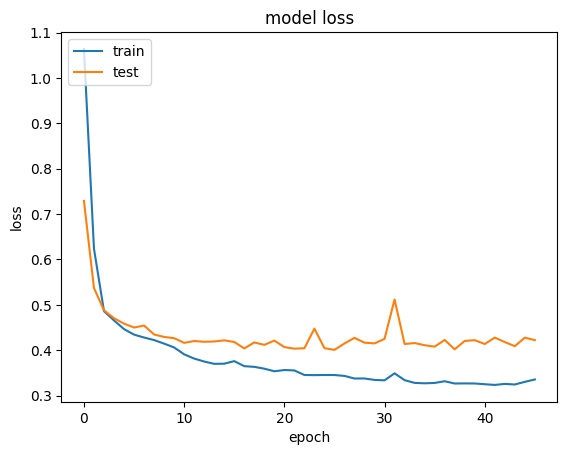

In [27]:
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'test'], loc = 'upper left')
plt.show()

In [28]:
# making the predictions and evaluating the model
y_pred = classifier.predict(X_test)
y_pred = (y_pred >= 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [29]:
# make the confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[1519,   76],
       [ 219,  186]])

In [30]:
# calculating the accuracy
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_pred, y_test)
acc

0.8525

In [31]:
# get the weights
classifier.get_weights()

[array([[-0.34313536, -0.33031136,  0.2748249 , -0.08307067, -0.322089  ,
         -0.06622457, -0.38360602, -0.23321311, -0.12798327, -0.16085383,
         -0.32787773],
        [ 0.05811694,  0.5063676 ,  0.45967087, -0.43282384, -0.05581374,
          0.6216102 ,  0.104334  , -0.21779922,  0.60041195,  0.39338344,
         -0.45636034],
        [-0.17940511, -0.07559001,  0.14982305,  0.04720125,  0.21715638,
         -0.10657924, -0.03568555, -0.04326391,  0.11589284,  0.25706902,
         -0.33577758],
        [-0.18314861, -0.56479573, -0.19936326,  0.00919156, -0.53766966,
          0.07218992,  0.6638393 ,  0.40888193,  0.00993167,  0.3401899 ,
          0.09706759],
        [ 0.15962446, -0.05596135, -0.289818  ,  0.31969988, -0.33711722,
         -0.4298496 , -0.53072745,  0.73351383,  0.74315774, -0.12049038,
          0.16890632],
        [-0.35249755,  0.06283781, -0.15196154, -0.2193991 , -0.00311214,
         -0.4144631 ,  0.28732568,  0.4667347 , -0.22209093, -0.3893306

In [33]:
classifier.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 815 (3.19 KB)

 Trainable params: 271 (1.06 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 544 (2.13 KB)

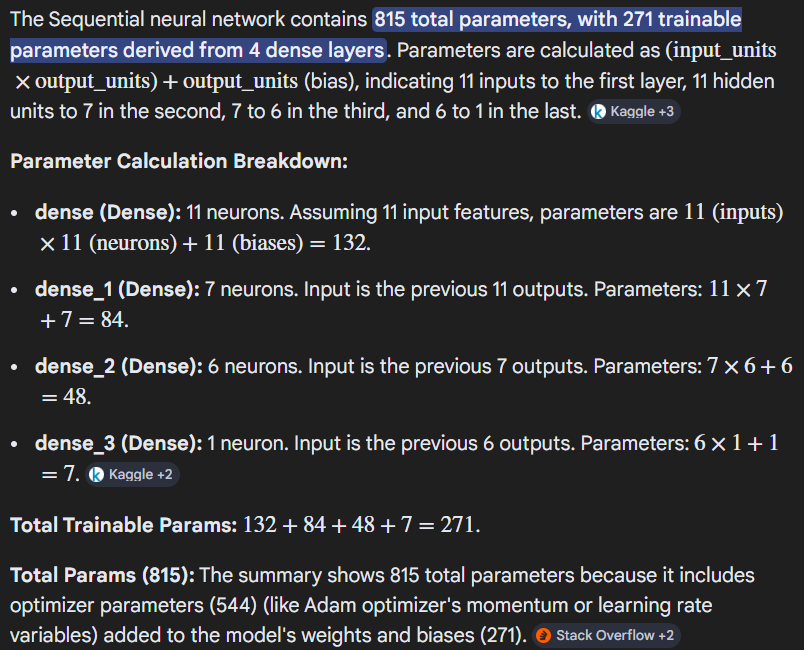